In [12]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset

import time
import matplotlib.pyplot as plt

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cuda


In [5]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [6]:
# Small subset sizes
TRAIN_SIZE = 2000
TEST_SIZE = 500

# Number of classes in CIFAR-10
NUM_CLASSES = 10

# Number of epochs
EPOCHS = 5

# Batch size
BATCH_SIZE = 32

In [7]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [8]:
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [9]:
# 4. DOWNLOAD CIFAR-10
full_train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=train_transform
)

100%|██████████| 170M/170M [10:14<00:00, 278kB/s]


In [10]:
full_test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=test_transform
)

In [13]:
# Select the first 2,000 training images
train_indices = list(range(TRAIN_SIZE))

# Select the first 500 test images
test_indices = list(range(TEST_SIZE))


train_dataset = Subset(
    full_train_dataset,
    train_indices
)


test_dataset = Subset(
    full_test_dataset,
    test_indices
)

In [14]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)


test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

In [15]:
print("\nDataset Information")
print("-------------------")
print("Training images:", len(train_dataset))
print("Testing images:", len(test_dataset))
print("Number of classes:", NUM_CLASSES)


Dataset Information
-------------------
Training images: 2000
Testing images: 500
Number of classes: 10


In [16]:
classes = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

print("Classes:", classes)

Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [17]:
def count_trainable_parameters(model):

    return sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )

In [18]:
# 9. TRAINING FUNCTION
def train_model(model, epochs=5, learning_rate=0.001):

    # Loss function
    criterion = nn.CrossEntropyLoss()

    # Only optimize parameters that are trainable
    optimizer = optim.Adam(
        filter(
            lambda parameter: parameter.requires_grad,
            model.parameters()
        ),
        lr=learning_rate
    )

    training_losses = []

    # Start timer
    start_time = time.time()

    # Training loop

    for epoch in range(epochs):

        model.train()

        running_loss = 0.0


        for images, labels in train_loader:

            # Move images and labels to device
            images = images.to(device)
            labels = labels.to(device)


            # Clear gradients
            optimizer.zero_grad()


            # Forward pass
            outputs = model(images)


            # Calculate loss
            loss = criterion(outputs, labels)


            # Backward pass
            loss.backward()


            # Update parameters
            optimizer.step()


            # Add loss
            running_loss += loss.item()


        # Calculate average loss
        epoch_loss = (
            running_loss / len(train_loader)
        )

        training_losses.append(epoch_loss)


        print(
            "Epoch [{}/{}] - Loss: {:.4f}".format(
                epoch + 1,
                epochs,
                epoch_loss
            )
        )


    # Calculate training time
    training_time = time.time() - start_time


    # TESTING

    model.eval()

    correct = 0
    total = 0


    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)


            # Get predictions
            outputs = model(images)


            _, predicted = torch.max(
                outputs,
                1
            )


            total += labels.size(0)

            correct += (
                predicted == labels
            ).sum().item()


    accuracy = 100 * correct / total


    return (
        training_losses,
        training_time,
        accuracy
    )

In [19]:
# EXPERIMENT A
# FROZEN FEATURE EXTRACTOR
print("\n")
print("=" * 60)
print("EXPERIMENT A: FROZEN FEATURE EXTRACTOR")
print("=" * 60)


# Load pretrained ResNet18
model_A = models.resnet18(
    weights="DEFAULT"
)




EXPERIMENT A: FROZEN FEATURE EXTRACTOR
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 164MB/s]


In [20]:
# Freeze all pretrained layers

for parameter in model_A.parameters():

    parameter.requires_grad = False


In [21]:
# Get number of inputs to final layer

num_features = model_A.fc.in_features

In [22]:
# Replace final classification layer

model_A.fc = nn.Linear(
    num_features,
    NUM_CLASSES
)


In [23]:
# Move model to device

model_A = model_A.to(device)

In [25]:
# Count trainable parameters

trainable_A = count_trainable_parameters(
    model_A
)
print(
    "Trainable parameters:",
    trainable_A
)

Trainable parameters: 5130


In [26]:
# Train model

loss_A, time_A, accuracy_A = train_model(
    model_A,
    epochs=EPOCHS,
    learning_rate=0.001
)


Epoch [1/5] - Loss: 1.7655
Epoch [2/5] - Loss: 1.1433
Epoch [3/5] - Loss: 0.9396
Epoch [4/5] - Loss: 0.8306
Epoch [5/5] - Loss: 0.7595


In [27]:
print("\nExperiment A Results")

print(
    "Training time: {:.2f} seconds".format(
        time_A
    )
)

print(
    "Test accuracy: {:.2f}%".format(
        accuracy_A
    )
)



Experiment A Results
Training time: 28.06 seconds
Test accuracy: 72.20%


In [28]:
# EXPERIMENT B
# FINE-TUNING

print("\n")
print("=" * 60)
print("EXPERIMENT B: FINE-TUNED NETWORK")
print("=" * 60)


# Load a fresh pretrained ResNet18

model_B = models.resnet18(
    weights="DEFAULT"
)


# Freeze everything first

for parameter in model_B.parameters():

    parameter.requires_grad = False


# Unfreeze the last convolutional block

for parameter in model_B.layer4.parameters():

    parameter.requires_grad = True


# Replace final classification layer

num_features = model_B.fc.in_features


model_B.fc = nn.Linear(
    num_features,
    NUM_CLASSES
)


# Move model to device

model_B = model_B.to(device)


# Count trainable parameters

trainable_B = count_trainable_parameters(
    model_B
)


print(
    "Trainable parameters:",
    trainable_B
)


# Train model

loss_B, time_B, accuracy_B = train_model(
    model_B,
    epochs=EPOCHS,
    learning_rate=0.001
)


print("\nExperiment B Results")

print(
    "Training time: {:.2f} seconds".format(
        time_B
    )
)

print(
    "Test accuracy: {:.2f}%".format(
        accuracy_B
    )
)





EXPERIMENT B: FINE-TUNED NETWORK
Trainable parameters: 8398858
Epoch [1/5] - Loss: 0.9284
Epoch [2/5] - Loss: 0.3990
Epoch [3/5] - Loss: 0.2656
Epoch [4/5] - Loss: 0.1794
Epoch [5/5] - Loss: 0.1522

Experiment B Results
Training time: 28.56 seconds
Test accuracy: 76.60%


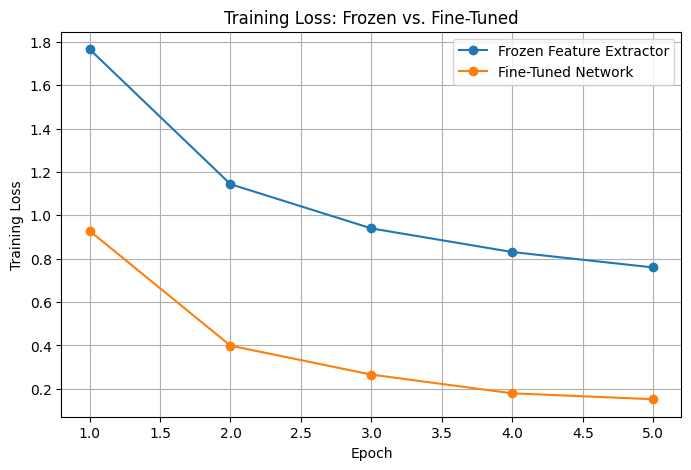

In [29]:
# PLOT TRAINING LOSS
epochs_range = range(
    1,
    EPOCHS + 1
)


plt.figure(figsize=(8, 5))


plt.plot(
    epochs_range,
    loss_A,
    marker="o",
    label="Frozen Feature Extractor"
)


plt.plot(
    epochs_range,
    loss_B,
    marker="o",
    label="Fine-Tuned Network"
)


plt.xlabel("Epoch")

plt.ylabel("Training Loss")

plt.title(
    "Training Loss: Frozen vs. Fine-Tuned"
)

plt.legend()

plt.grid(True)

plt.show()


In [30]:
# COMPARISON TABLE

print("\n")
print("=" * 90)
print("FINAL COMPARISON")
print("=" * 90)


print(
    "{:<25} {:<25} {:<20} {:<15}".format(
        "Method",
        "Trainable Parameters",
        "Training Time (sec)",
        "Accuracy (%)"
    )
)


print("-" * 90)


print(
    "{:<25} {:<25} {:<20.2f} {:<15.2f}".format(
        "Frozen Feature Extractor",
        trainable_A,
        time_A,
        accuracy_A
    )
)


print(
    "{:<25} {:<25} {:<20.2f} {:<15.2f}".format(
        "Fine-Tuned Network",
        trainable_B,
        time_B,
        accuracy_B
    )
)


print("=" * 90)



FINAL COMPARISON
Method                    Trainable Parameters      Training Time (sec)  Accuracy (%)   
------------------------------------------------------------------------------------------
Frozen Feature Extractor  5130                      28.06                72.20          
Fine-Tuned Network        8398858                   28.56                76.60          
